##  IMPA Tech - IMPA - Instituto de Matemática Pura e Aplicada

### Participantes: Natália e Heitor

## Análise em Python sobre os casos de VSR e Influenza no Brasil 
  



### Objetivo dessa análise consiste em determinar características epidêmicas para os estados brasieliros em relação ao VSR e Influenza e determinar clusters através dessas características. Bem como analisar brevemente o panorama geral de casos de Covid-19 no Brasil. 

## Bibliotecas necessárias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## Carregando a base de dados 

In [2]:

url = "https://github.com/infogripe/Boletim_InfoGripe/raw/refs/heads/main/Dados/InfoGripe/casos_semanais_fx_etaria_virus_sem_filtro_febre.csv"

df = pd.read_csv(url, sep=";")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 182294 entries, 0 to 182293
Data columns (total 36 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   SG_UF_NOT              182294 non-null  int64
 1   fx_etaria              182294 non-null  str  
 2   SRAG                   182294 non-null  int64
 3   SARS2                  182294 non-null  int64
 4   VSR                    182294 non-null  int64
 5   FLU                    182294 non-null  int64
 6   FLU_A                  182294 non-null  int64
 7   FLU_AH1N1              182294 non-null  int64
 8   FLU_AH3N2              182294 non-null  int64
 9   FLU_ANSUBTPD           182294 non-null  int64
 10  FLU_ANSUBTPV           182294 non-null  int64
 11  FLU_AINC               182294 non-null  int64
 12  FLU_AOUT               182294 non-null  int64
 13  FLU_B                  182294 non-null  int64
 14  FLU_BVIC               182294 non-null  int64
 15  FLU_BYAM               18229

C:\Users\Lya\AppData\Local\Temp\ipykernel_23988\741302333.py:3: DtypeWarning: Columns (0: DS_UF_SIGLA) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, sep=";")


In [3]:
df.head()

,SG_UF_NOT,fx_etaria,SRAG,SARS2,VSR,FLU,FLU_A,FLU_AH1N1,FLU_AH3N2,FLU_ANSUBTPD,...,PARA4,OUTROS,positivos,negativos,aguardando,DS_UF_SIGLA,epiyear,epiweek,Semana epidemiológica,Ano epidemiológico
0,0,< 2,1,0,0,0,0,0,0,0,...,0,0,0,1,0,BR,2009,16,16,2009
1,0,< 2,3,0,0,1,1,0,0,0,...,0,1,2,0,0,BR,2009,17,17,2009
2,0,< 2,1,0,0,0,0,0,0,0,...,0,0,0,1,0,BR,2009,18,18,2009
3,0,< 2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,BR,2009,19,19,2009
4,0,< 2,1,0,0,0,0,0,0,0,...,0,0,0,1,0,BR,2009,20,20,2009


## Analisando os casos de vsr (ignorando a faixa etária) de 2009 - 2026 

In [4]:
vsr = (
    df.groupby(
        ["DS_UF_SIGLA", "epiyear", "epiweek"]
    )["VSR"]
    .sum()
    .reset_index()
)

vsr.head()

,DS_UF_SIGLA,epiyear,epiweek,VSR
0,AC,2009,16,0
1,AC,2009,17,0
2,AC,2009,18,0
3,AC,2009,19,0
4,AC,2009,20,0


## Limpeza dos dados 

In [5]:
vsr.info()

<class 'pandas.DataFrame'>
RangeIndex: 25144 entries, 0 to 25143
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   DS_UF_SIGLA  25144 non-null  str  
 1   epiyear      25144 non-null  int64
 2   epiweek      25144 non-null  int64
 3   VSR          25144 non-null  int64
dtypes: int64(3), str(1)
memory usage: 838.1 KB


In [6]:
# checando se há valores duplicados
vsr.duplicated().sum()

np.int64(0)

In [7]:
# checando se não há estados estranhos 
sorted(vsr["DS_UF_SIGLA"].unique())

['AC',
 'AL',
 'AM',
 'AP',
 'BA',
 'BR',
 'CE',
 'DF',
 'ES',
 'GO',
 'MA',
 'MG',
 'MS',
 'MT',
 'PA',
 'PB',
 'PE',
 'PI',
 'PR',
 'RJ',
 'RN',
 'RO',
 'RR',
 'RS',
 'SC',
 'SE',
 'SP',
 'TO']

In [8]:
# checando se as semanas epidemiológicas são válidas
vsr["epiweek"].describe()

count    25144.000000
mean        26.521158
std         14.986190
min          1.000000
25%         14.000000
50%         26.000000
75%         39.000000
max         53.000000
Name: epiweek, dtype: float64

In [9]:
# checando se há casos negativos 
(vsr["VSR"] < 0).sum()

np.int64(0)

Antes da análise, a base foi inspecionada para verificar possíveis problemas nos dados. Não foram encontrados valores nulos ou inconsistências nas variáveis utilizadas.

### Visualizando os dados de 2009 e 2010

In [10]:
vsr[vsr["epiyear"] == 2009]

,DS_UF_SIGLA,epiyear,epiweek,VSR
0,AC,2009,16,0
1,AC,2009,17,0
2,AC,2009,18,0
3,AC,2009,19,0
4,AC,2009,20,0
...,...,...,...,...
24278,TO,2009,48,0
24279,TO,2009,49,0
24280,TO,2009,50,0
24281,TO,2009,51,0


In [11]:
vsr[vsr["epiyear"] == 2010]

,DS_UF_SIGLA,epiyear,epiweek,VSR
37,AC,2010,1,0
38,AC,2010,2,0
39,AC,2010,3,0
40,AC,2010,4,0
41,AC,2010,5,0
...,...,...,...,...
24330,TO,2010,48,0
24331,TO,2010,49,0
24332,TO,2010,50,0
24333,TO,2010,51,0


Note que a cada ano tem a semana 1, 2, ..., para facilitar nossa análise, adicionaremos uma nova coluna de forma que o número da semana seja crescente.

In [12]:
# ignorando os estados por enquanto
vsr_global = (
    vsr.groupby(["epiyear", "epiweek"])["VSR"]
       .sum()
       .reset_index()
)

vsr_global.head()

,epiyear,epiweek,VSR
0,2009,16,0
1,2009,17,0
2,2009,18,0
3,2009,19,0
4,2009,20,0


In [13]:
# adicioanndo nova coluna 
vsr_global["semana_global"] = range(1, len(vsr_global) + 1)

vsr_global

,epiyear,epiweek,VSR,semana_global
0,2009,16,0,1
1,2009,17,0,2
2,2009,18,0,3
3,2009,19,0,4
4,2009,20,0,5
...,...,...,...,...
893,2026,22,7872,894
894,2026,23,6952,895
895,2026,24,5708,896
896,2026,25,3364,897


### Panorama geral de casos de VSR no Brasil no período de 2009 a 2026

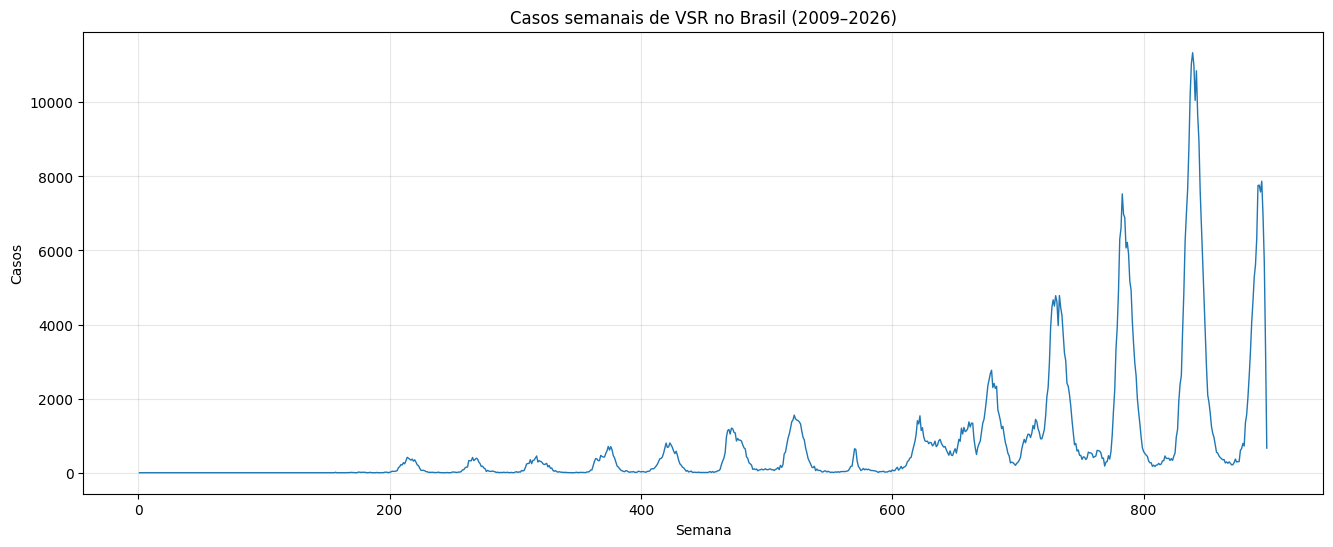

In [14]:
plt.figure(figsize=(16,6))

plt.plot(
    vsr_global["semana_global"],
    vsr_global["VSR"],
    linewidth=1
)

plt.title("Casos semanais de VSR no Brasil (2009–2026)")
plt.xlabel("Semana")
plt.ylabel("Casos")
plt.grid(alpha=0.3)

plt.show()

É notório que os casos de VSR apresentam picos anuais ao longo de toda a série, porém esses picos se tornam muito maiores a partir de 2019, principalmente nos anos mais recentes. É importante ressaltar que esse aumento não significa necessariamente que a circulação do vírus tenha aumentado. Uma possível explicação para isso é que o sistema de vigilância passou por um processo de consolidação a partir de 2019, tornando os registros mais confiáveis.

## Análise de VSR de 2019 - 2025

Nosso objetivo consiste em realizar 3 filtros para determinar se uma dada semana foi ou não uma epidemia.

Como nossa análise considera cinco anos (2019, 2022, 2023, 2024 e 2025), em vez de analisar apenas a semana x, utilizaremos também as semanas x−2, x−1, x, x+1 e x+2. Dessa forma, a amostra deixa de ter apenas 5 observações e passa a conter 25 observações.

Filtramos os anos de 2018 a 2026, pois a construção da amostra
utiliza os anos de 2019, 2022, 2023, 2024 e 2025, além das semanas
vizinhas. Assim, 2018 e 2026 são mantidos para permitir o tratamento
das semanas de borda (1 e 52).

In [15]:
vsr_filtrado = vsr[
    ((2018 <= vsr["epiyear"]) &(vsr["epiyear"] <= 2026))
].copy()
vsr_filtrado = vsr_filtrado.reset_index(drop=True)
vsr_filtrado.head()

,DS_UF_SIGLA,epiyear,epiweek,VSR
0,AC,2018,1,0
1,AC,2018,2,0
2,AC,2018,3,2
3,AC,2018,4,0
4,AC,2018,5,0


Essa função é responsável por selecionar os dados de um único estado a partir do DataFrame vsr_filtrado.

In [16]:
def filtrar_estado(x):
  saida = vsr_filtrado[ (vsr_filtrado['DS_UF_SIGLA'] == x)].copy()
  saida = saida.reset_index(drop=True)
  return saida

A função filtrar_ano recebe um DataFrame e um ano epidemiológico como parâmetros, retornando apenas os registros correspondentes a esse ano.

In [17]:
def filtrar_ano(x,n):
  saida = x[ (x['epiyear'] == n)].copy()
  saida = saida.reset_index(drop=True)
  return saida


A função filtrar_amostra recebe:

x: o DataFrame de um estado;
n: a semana epidemiológica que se deseja analisar.

Ela retorna uma lista contendo 25 observações, correspondentes às semanas x−2, x−1, x, x+1 e x+2 dos anos de 2019, 2022, 2023, 2024 e 2025.

Essas 25 observações serão utilizadas posteriormente para calcular os limiares dos filtros.

In [18]:
def filtrar_amostra(x,n):
  amostra = []
  if n==1:
    for i in [2019, 2022,2023,2024,2025]:
      M=filtrar_ano(x,i)
      N=filtrar_ano(x,i-1)
      amostra.append(int(N.loc[N['epiweek'] == 51, 'VSR'].values[0]))
      amostra.append(int(N.loc[N['epiweek'] == 52, 'VSR'].values[0]))
      for j in range(n, n+3):
        amostra.append(int(M.loc[M['epiweek'] == j, 'VSR'].values[0]))
  elif n==2:
    for i in [2019, 2022,2023,2024,2025]:
      M=filtrar_ano(x,i)
      N=filtrar_ano(x,i-1)
      amostra.append(int(N.loc[N['epiweek'] == 52, 'VSR'].values[0]))
      for j in range(n-1, n+3):
        amostra.append(int(M.loc[M['epiweek'] == j, 'VSR'].values[0]))
  elif n>=3 and n<=50:
    for i in [2019, 2022,2023,2024,2025]:
      M=filtrar_ano(x,i)
      for j in range(n-2, n+3):
        amostra.append(int(M.loc[M['epiweek'] == j, 'VSR'].values[0]))
  elif n==51:
    for i in [2019, 2022,2023,2024]:
        M=filtrar_ano(x,i)
        N=filtrar_ano(x,i+1)
        for j in range(n-2, n+2):
          amostra.append(int(M.loc[M['epiweek'] == j, 'VSR'].values[0]))
        amostra.append(int(N.loc[N['epiweek'] == 1, 'VSR'].values[0]))
    M=filtrar_ano(x,2025)
    for j in range(n-2, n+3):
        amostra.append(int(M.loc[M['epiweek'] == j, 'VSR'].values[0]))
  else:
    for i in [2019, 2022,2023,2024]:
        M=filtrar_ano(x,i)
        N=filtrar_ano(x,i+1)
        for j in range(n-2, n+1):
          amostra.append(int(M.loc[M['epiweek'] == j, 'VSR'].values[0]))
        amostra.append(int(N.loc[N['epiweek'] == 1, 'VSR'].values[0]))
        amostra.append(int(N.loc[N['epiweek'] == 2, 'VSR'].values[0]))
    M=filtrar_ano(x,2025)
    N=filtrar_ano(x,2026)
    for j in range(n-2, n+2):
        amostra.append(int(M.loc[M['epiweek'] == j, 'VSR'].values[0]))
    amostra.append(int(N.loc[N['epiweek'] == 1, 'VSR'].values[0]))
  return amostra

Filtro 1) Vamos estabelecer uma incidência mínima nessa semana, ela vai ser dado um periodo x, a média + 2*desvio padrão. Sendo esse período o verão (semana 52 até semana 11) para estados do centro oeste, sudeste e sul, e a primavera (semana 38 a 51 no norte e nordeste)

Fitro 2) Com os dados dessas 25 semanas, é calculado a média. A incidencia precisa estar acima de 1.5*média.

FIltro 3) Os casos dessa semana precisam estar acima da percentil 80 dessas 25 semanas.

Caso passe em todos os 3 filtros é considerado uma epidemia